# 03 - Analisis exploratorio profundo

**Responsable:** Cesar Rojas  
**Etapa:** Data Understanding posterior a Data Preparation (CRISP-DM)

Este notebook recibe el dataset limpio de Ignacio Silva y profundiza los patrones asociados
con `popularity`. Lucas Moncada documentó el problema, la fuente y los hallazgos iniciales;
Ignacio retiró la fila inválida y consolidó cada `track_id`. Por eso la unidad analítica es una
canción única: evita doble conteo por género y fuga del mismo track entre particiones futuras.
El análisis es descriptivo y asociativo; no establece causalidad ni entrena modelos.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from spotify_popularity.analysis.exploratory import (
    NUMERIC_FEATURES,
    expanded_genre_summary,
    iqr_outlier_summary,
    popularity_summary,
    target_correlations,
    validate_processed_dataset,
)
from spotify_popularity.config import PROJECT_PATHS
from spotify_popularity.visualization.distributions import (
    plot_binned_popularity,
    plot_correlation_heatmap,
    save_figure,
)

sns.set_theme(style="whitegrid", context="notebook")
data_path = PROJECT_PATHS.data_processed / "spotify_tracks_clean.csv"
if not data_path.exists():
    raise FileNotFoundError(
        "No existe el dataset procesado. Ejecute: uv run python scripts/build_processed_dataset.py"
    )
data = pd.read_csv(data_path)
figures_path = PROJECT_PATHS.figures
figures_path.mkdir(parents=True, exist_ok=True)

## 1. Validacion del dataset procesado

Esta sección comprueba el contrato de entrada, sin repetir limpieza: 89.740 filas, 20
columnas, una fila por `track_id`, sin nulos y con duración positiva. La estructura esperada
corresponde al registro de Ignacio, incluido `track_genres` como etiqueta multivaluada.

In [2]:
controls = validate_processed_dataset(data)
print(controls)
display(data.dtypes.rename("tipo"))
display(data.describe(include="all").T[["count", "min", "max"]])
assert controls["shape"] == (89_740, 20)
assert controls["missing_cells"] == 0
assert controls["duplicate_track_ids"] == 0
assert controls["non_positive_durations"] == 0

{'shape': (89740, 20), 'missing_cells': 0, 'unique_track_ids': 89740, 'duplicate_track_ids': 0, 'non_positive_durations': 0, 'empty_genres': 0}


track_id             object
artists              object
album_name           object
track_name           object
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
popularity          float64
track_genres         object
Name: tipo, dtype: object

,count,min,max
track_id,89740,NaN,NaN
artists,89740,NaN,NaN
album_name,89740,NaN,NaN
track_name,89740,NaN,NaN
duration_ms,89740.0,8586.0,5237295.0
explicit,89740,NaN,NaN
danceability,89740.0,0.0,0.985
energy,89740.0,0.0,1.0
key,89740.0,0.0,11.0
loudness,89740.0,-49.531,4.532


## 2. Popularidad actualizada

La consolidación por `track_id` usa la mediana cuando había asignaciones históricas distintas;
por ello este resumen no tiene por qué coincidir con las 114.000 filas originales. Al eliminar
repetición por género se modifica la ponderación implícita de cada canción.

,valor
media,33.198
mediana,33.000
desviacion_estandar,20.578
minimo,0.000
p25,19.000
p75,49.000
p95,67.000
maximo,100.000
proporcion_cero_pct,10.468
proporcion_70_o_mas_pct,3.480


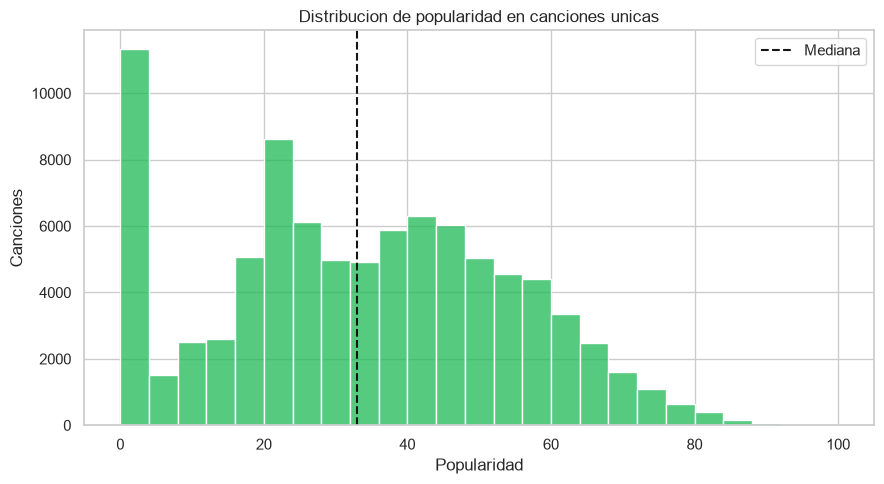

In [3]:
popularity_stats = popularity_summary(data).round(3)
display(popularity_stats.to_frame("valor"))
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=data, x="popularity", bins=25, color="#1DB954", ax=ax)
ax.axvline(data["popularity"].median(), color="#191414", linestyle="--", label="Mediana")
ax.set(
    title="Distribucion de popularidad en canciones unicas",
    xlabel="Popularidad",
    ylabel="Canciones",
)
ax.legend()
fig.tight_layout()
save_figure(fig, figures_path / "05_processed_popularity_distribution.png")
plt.show()

**Interpretación.** La media y mediana describen un catálogo con predominio bajo-medio; los
extremos 0 y 100 son valores permitidos por la escala, no errores por sí mismos. La proporción
en cero baja respecto de las filas originales (14,05% a aproximadamente 10,47%) y el segmento
>=70 también baja (4,8% a aproximadamente 3,48%), consistente con retirar repeticiones y
resumir popularidad por canción.

## 3. Relaciones numericas con `popularity`

Pearson resume asociación lineal y Spearman asociación monotónica por rangos. Reportar ambas
reduce la dependencia de una sola forma funcional; sus valores miden asociación, no efecto.

In [4]:
target_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
]
correlations = target_correlations(data, target_features)
display(correlations.round(4))

,pearson,spearman
variable,,
instrumentalness,-0.1275,-0.1244
loudness,0.0717,0.0673
speechiness,-0.0471,-0.0670
danceability,0.0643,0.0553
energy,0.0138,-0.0156
duration_ms,-0.0232,0.0127
liveness,-0.0139,-0.0115
valence,-0.0115,-0.0107
acousticness,-0.0389,0.0101


**Interpretación.** Las asociaciones son débiles: `instrumentalness` presenta la señal negativa
más visible, mientras `loudness` y `danceability` son positivas pero pequeñas. Las restantes son
cercanas a cero. Esto anticipa que atributos de audio aislados difícilmente expliquen por sí
solos la popularidad y que variables contextuales podrían aportar señal, con cautela ante fuga.

## 4. Matriz de correlacion y redundancia

Además de observar el objetivo, se revisan relaciones entre predictores para anticipar
redundancia o multicolinealidad en modelos lineales.

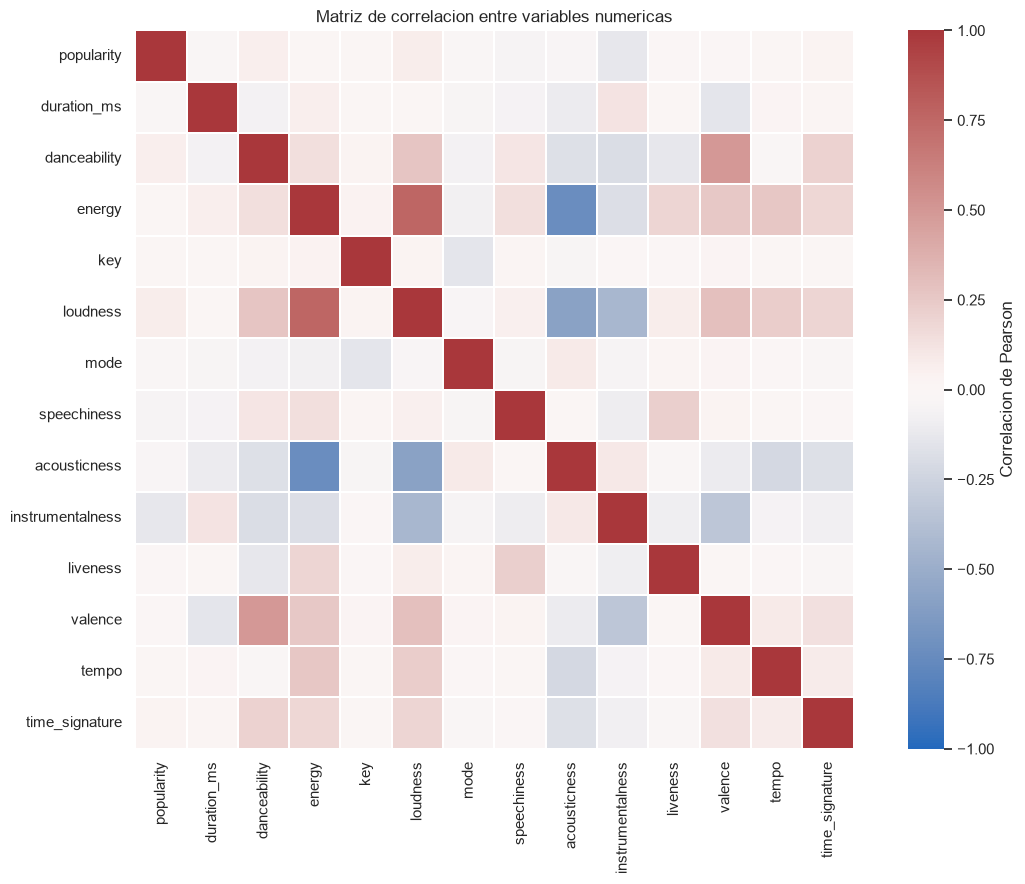

,,correlacion
energy,loudness,0.758774
loudness,energy,0.758774
acousticness,energy,-0.732569
energy,acousticness,-0.732569
loudness,acousticness,-0.582664
acousticness,loudness,-0.582664
danceability,valence,0.492578
valence,danceability,0.492578
loudness,instrumentalness,-0.434719
instrumentalness,loudness,-0.434719


In [5]:
numeric_correlation = data.loc[:, NUMERIC_FEATURES].corr()
figure = plot_correlation_heatmap(numeric_correlation)
save_figure(figure, figures_path / "06_numeric_correlation_heatmap.png")
plt.show()

pairs = numeric_correlation.where(
    ~__import__("numpy").eye(len(numeric_correlation), dtype=bool)
).stack()
display(
    pairs.sort_values(key=lambda values: values.abs(), ascending=False)
    .head(12)
    .to_frame("correlacion")
)

**Hallazgo.** `energy`-`loudness` (~0,76) y `energy`-`acousticness` (~-0,73) son relaciones
fuertes. En modelamiento conviene evaluar regularización, diagnósticos de colinealidad o
seleccionar representaciones, sin retirar variables en esta etapa solo por correlación.

## 5. Profundizacion bivariada

Con casi 90 mil observaciones, un scatterplot ocultaría densidad. Se emplean cuantiles y la
mediana por intervalo, robusta frente a colas y fácil de comparar.

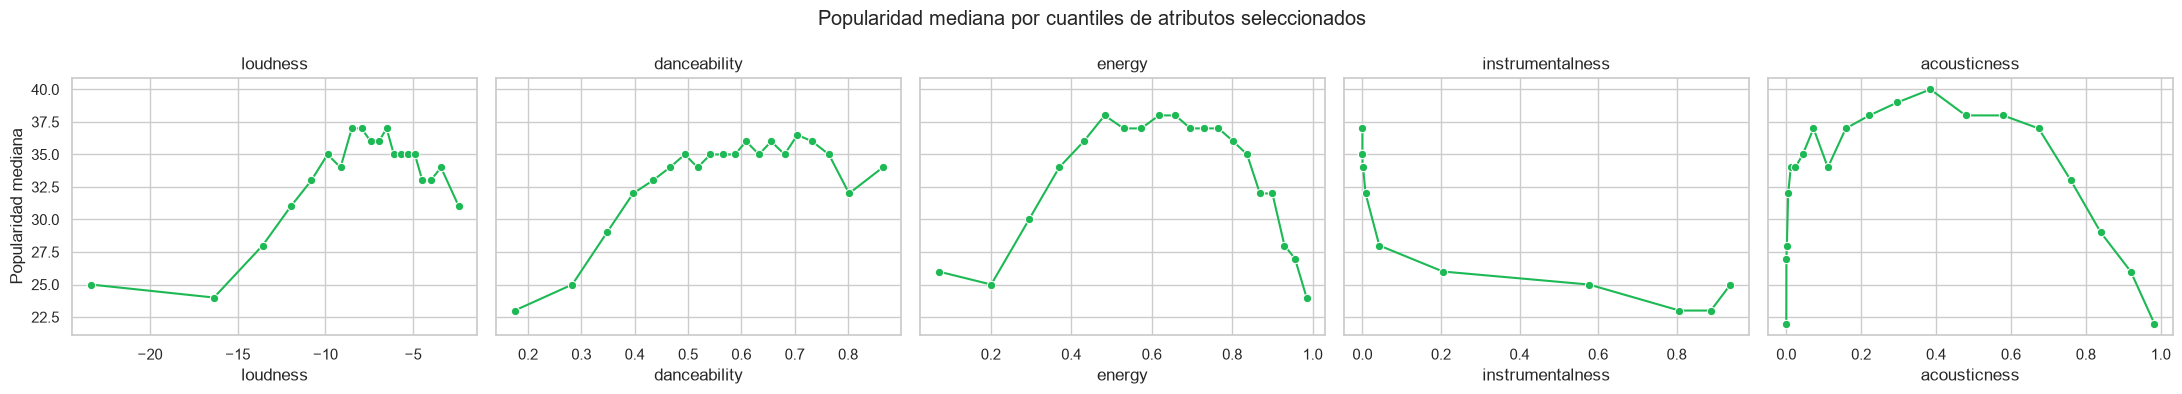

In [6]:
selected = ["loudness", "danceability", "energy", "instrumentalness", "acousticness"]
fig, axes = plt.subplots(1, len(selected), figsize=(22, 4), sharey=True)
for axis, feature in zip(axes, selected, strict=True):
    binned = data.loc[:, [feature, "popularity"]].copy()
    binned["bin"] = pd.qcut(binned[feature], q=20, duplicates="drop")
    summary = binned.groupby("bin", observed=True).agg(
        x=(feature, "median"), y=("popularity", "median")
    )
    sns.lineplot(data=summary, x="x", y="y", marker="o", color="#1DB954", ax=axis)
    axis.set(title=feature, xlabel=feature, ylabel="Popularidad mediana")
fig.suptitle("Popularidad mediana por cuantiles de atributos seleccionados")
fig.tight_layout()
save_figure(fig, figures_path / "07_binned_feature_popularity.png")
plt.show()

single_feature_figure = plot_binned_popularity(data, "instrumentalness")
plt.close(single_feature_figure)

La caída de la popularidad mediana con `instrumentalness` es la tendencia más consistente; las
curvas de `loudness` y `danceability` son suaves y pequeñas. `energy` y `acousticness` no
justifican una regla simple. Las tendencias son descriptivas y pueden reflejar géneros,
recencia o estrategias de catálogo no observadas.

## 6. Contenido explicito y popularidad

El indicador describe clasificación de contenido, no una intervención ni una propiedad que
pueda interpretarse causalmente.

,count,mean,median,std
explicit,,,,
False,82036,32.852,33.0,20.369
True,7704,36.884,37.0,22.352


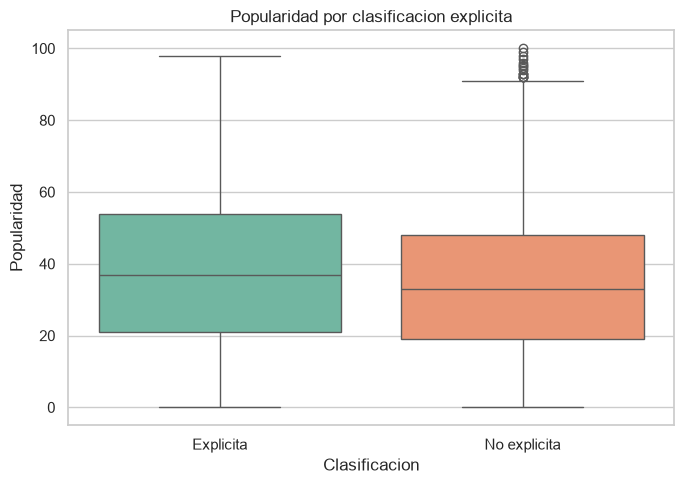

In [7]:
explicit_summary = data.groupby("explicit")["popularity"].agg(["count", "mean", "median", "std"])
display(explicit_summary.round(3))
fig, ax = plt.subplots(figsize=(7, 5))
labels = data["explicit"].map({False: "No explicita", True: "Explicita"})
sns.boxplot(x=labels, y=data["popularity"], hue=labels, legend=False, palette="Set2", ax=ax)
ax.set(
    title="Popularidad por clasificacion explicita", xlabel="Clasificacion", ylabel="Popularidad"
)
fig.tight_layout()
save_figure(fig, figures_path / "08_explicit_popularity_boxplot.png")
plt.show()

Las canciones explícitas muestran media y mediana descriptivamente mayores, pero también una
dispersión mayor y un tamaño mucho menor. La diferencia puede estar confundida por género,
público, fecha o promoción; no demuestra que el contenido explícito incremente popularidad.

## 7. Generos y popularidad

`track_genres` se expande por `|`. Una canción puede aparecer en varias etiquetas: las filas
expandidas **no son canciones únicas adicionales**. Para evitar rankings engañosos se muestran
solo géneros con al menos 100 canciones (en este insumo, el soporte es cercano a mil).

,genre,canciones,popularidad_media,popularidad_mediana,desviacion_estandar
80,pop,993,47.90,66.0,33.93
81,pop-film,999,59.28,60.0,10.25
65,k-pop,998,56.96,60.0,16.86
51,hip-hop,991,38.08,58.0,32.52
15,chill,999,53.70,57.0,14.85
71,metal,998,43.68,57.0,30.01
44,grunge,999,49.58,55.0,18.49
94,sad,1000,52.40,54.0,11.51
11,british,1000,43.80,52.0,23.44
83,progressive-house,999,46.72,52.0,20.04


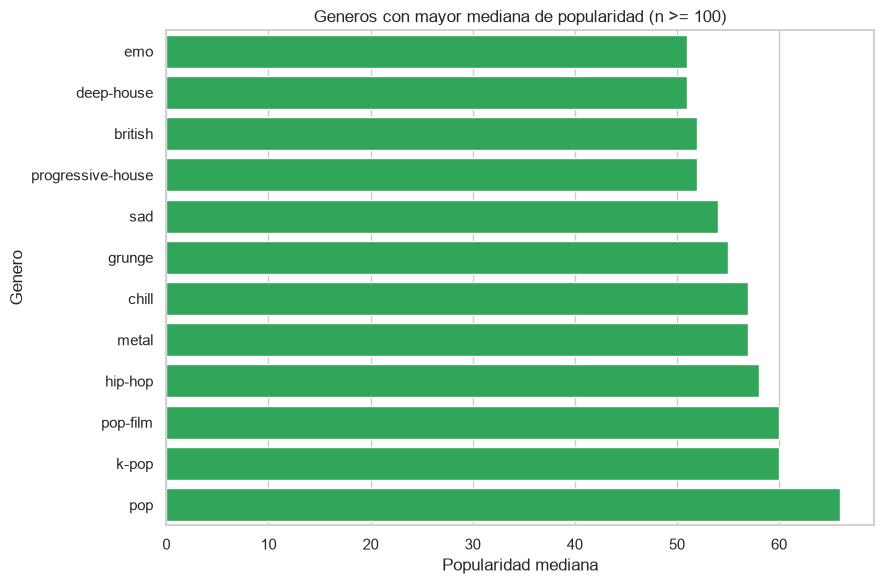

In [8]:
genre_summary = expanded_genre_summary(data, minimum_count=100)
display(genre_summary.head(15).round(2))
top_genres = genre_summary.head(12).sort_values("popularidad_mediana")
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_genres, x="popularidad_mediana", y="genre", color="#1DB954", ax=ax)
ax.set(
    title="Generos con mayor mediana de popularidad (n >= 100)",
    xlabel="Popularidad mediana",
    ylabel="Genero",
)
fig.tight_layout()
save_figure(fig, figures_path / "09_genre_popularity_summary.png")
plt.show()

Los géneros con medianas altas describen la muestra disponible, no prevalencia en Spotify: el
origen tenía cobertura artificialmente balanceada por etiqueta. La interpretación debe mantener
el tamaño muestral, la multietiqueta y la amplia dispersión por género.

## 8. Valores extremos y anomalias

IQR se usa como señal de revisión, no como regla de eliminación. En atributos acotados, muchos
puntos fuera del IQR pueden ser valores musicales válidos por acumulación en cero.

,minimo,p1,p99,maximo,limite_inferior_iqr,limite_superior_iqr,casos_fuera_iqr
variable,,,,,,,
duration_ms,8586.000,61871.850,546010.980,5237295.000,36160.500,401172.500,4225
tempo,0.000,65.165,193.652,243.372,38.041,201.298,514
loudness,-49.531,-28.542,-1.628,4.532,-18.144,2.713,5026
speechiness,0.000,0.026,0.619,0.965,-0.039,0.161,10644
instrumentalness,0.000,0.000,0.958,1.000,-0.146,0.244,19613
liveness,0.000,0.041,0.950,1.000,-0.173,0.550,6981


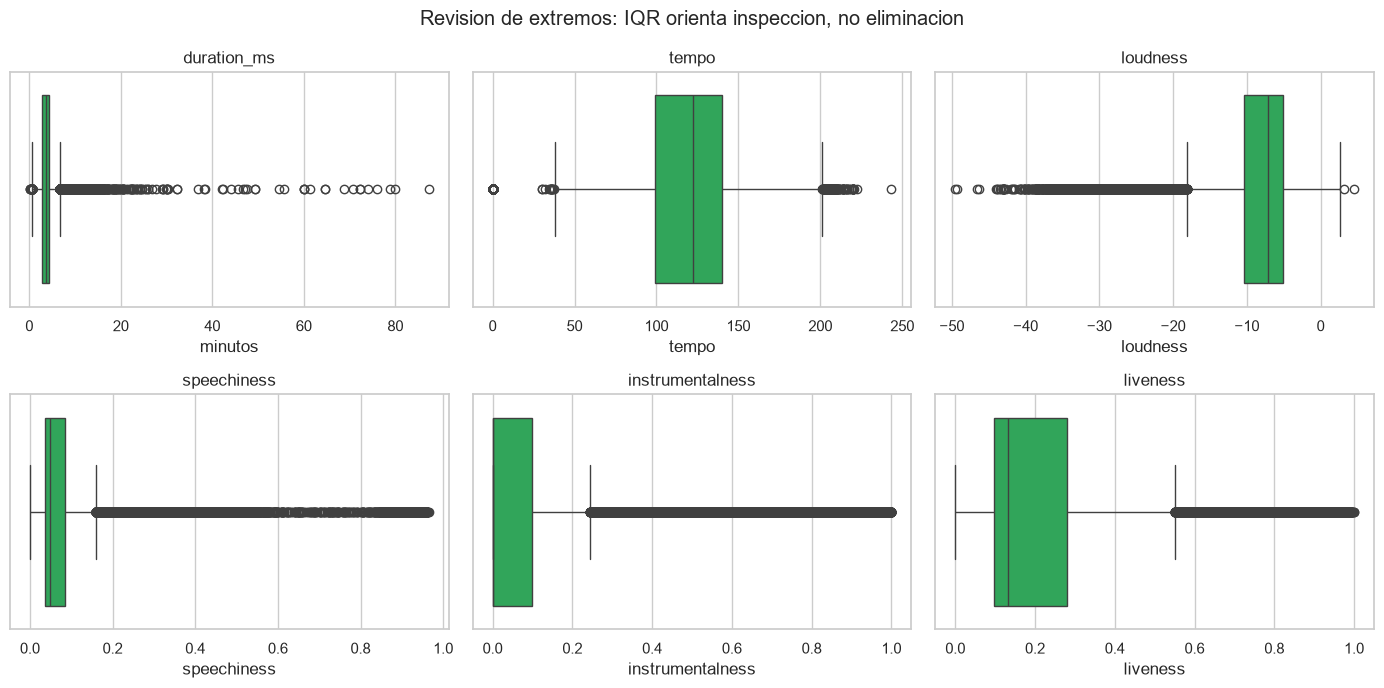

In [9]:
outlier_features = [
    "duration_ms",
    "tempo",
    "loudness",
    "speechiness",
    "instrumentalness",
    "liveness",
]
outliers = iqr_outlier_summary(data, outlier_features)
display(outliers.round(3))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for axis, feature in zip(axes.flat, outlier_features, strict=True):
    values = data[feature] / 60_000 if feature == "duration_ms" else data[feature]
    sns.boxplot(x=values, color="#1DB954", ax=axis)
    axis.set(title=feature, xlabel="minutos" if feature == "duration_ms" else feature)
fig.suptitle("Revision de extremos: IQR orienta inspeccion, no eliminacion")
fig.tight_layout()
save_figure(fig, figures_path / "10_outlier_review.png")
plt.show()

`duration_ms` tiene una cola larga (máximo cercano a 87 minutos), `tempo` incluye cero y
`loudness` alcanza valores inusuales. Son candidatos a validación puntual y transformaciones
robustas (por ejemplo, `log1p` para duración), no evidencia suficiente para borrarlos. Los
extremos de `speechiness`, `instrumentalness` y `liveness` son coherentes con variables de
Spotify acotadas entre 0 y 1; se conservan.

## 9. Variables para modelamiento

| Variable o grupo | Evidencia EDA | Riesgo/limitacion | Recomendacion |
|---|---|---|---|
| `popularity` | Objetivo con masa en cero y cola alta | Medida histórica, dependiente de recencia | Target de regresión; reportar distribución y errores por segmento |
| Atributos acústicos | Señales individuales débiles; `instrumentalness` destaca negativamente | No causalidad y colinealidad audio | Candidatas; escalar según modelo |
| `duration_ms`, `tempo`, `loudness` | Colas y extremos | Sensibilidad a outliers | Revisar rangos y usar transformaciones/escala robusta |
| `track_genres` | Segmentación informativa | Multietiqueta y muestra balanceada artificialmente | Multi-hot con validación; no inferir frecuencia real |
| `explicit` | Diferencia descriptiva entre grupos | Posibles confusores sociales y de género | Variable binaria candidata, auditar desempeño por grupo |
| `artists`, `track_name`, `album_name` | Contexto potencialmente informativo | Alta cardinalidad y memorization | No usar sin estrategia estricta de encoding y validación temporal |
| `track_id` | Identificador único | Leakage/memorization | Excluir de predictores; conservar para trazabilidad y particiones |

## 10. Sesgos, etica, privacidad y limitaciones

**Sesgos observables.** La cobertura original presenta 1.000 filas por género, por lo que no
representa la composición natural del catálogo. La consolidación reduce ese artefacto, pero no
elimina el sesgo de selección de la fuente. La popularidad es histórica y depende de
reproducciones y recencia; no hay fecha de extracción, región, marketing, playlists, viralidad,
popularidad previa del artista ni variables de audiencia. Estos factores son limitaciones o
hipótesis razonables, no efectos demostrados por esta tabla.

**Ética.** Un modelo puede reforzar la ventaja de artistas ya expuestos, homogeneizar decisiones
creativas, perjudicar indirectamente estilos menos representados y convertir correlaciones en
falsas reglas de éxito. Debe servir como apoyo, con revisión humana, monitoreo por grupos y sin
asignar automáticamente presupuesto o promoción.

**Privacidad.** El dataset contiene metadatos de canciones, artistas y atributos musicales; no
incluye directamente datos personales ni comportamiento de oyentes, por lo que el riesgo
individual es menor. Aun así, se debe mantener trazabilidad de fuente y transformaciones,
respetar condiciones de uso documentadas y no vincular estos datos con perfiles de usuarios sin
una base legal y controles adicionales.

**Limitaciones.** Es una fotografía histórica, sin variables contextuales clave; popularidad es
imperfecta y no causal; la muestra puede no ser representativa y existe información no observada.

## 11. Conclusiones y entrega a modelamiento

El dataset validado contiene 89.740 canciones únicas sin nulos ni duraciones no positivas. La
popularidad se concentra en valores bajos y medios; ninguna característica acústica presenta una
asociación fuerte con el target. `instrumentalness`, `loudness` y `danceability` son candidatas
para evaluación multivariable, mientras la colinealidad entre energía, sonoridad y acousticness
exige regularización o diagnóstico. Para el siguiente equipo: excluir `track_id`; tratar texto y
artista como alta cardinalidad; codificar correctamente géneros múltiples; conservar extremos
salvo evidencia de error; dividir respetando IDs (ya únicos) y, si se dispone de fechas futuras,
preferir una partición temporal. Evaluar MAE, RMSE y R² junto con análisis por grupos, no solo una
métrica global.